# Notebook 03 — Topic Mining (LDA)

**Project:** CX Intelligence — NPS & Complaint Severity Analysis  
**Author:** Nicolás Zuleta Sierra

## Objectives
1. Discover recurring themes in banking complaints via LDA
2. Select optimal number of topics using held-out perplexity (sklearn, no gensim dependency)
3. Name each topic with banking domain expertise
4. Identify the top drivers of customer dissatisfaction by NPS
5. Cross-analyse topics with NPS and complaint severity

**Input:** `data/processed/features_nlp.csv`  
**Output:** `dominant_topic` column added · `models/lda_model.pkl` serialized

## 0. Imports & Configuration

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import spacy
from wordcloud import WordCloud

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

from src.topics import (
    assign_topics,
    build_tfidf_matrix,
    calculate_coherence,
    get_topic_keywords,
    preprocess_for_lda,
    save_lda_model,
    train_lda,
)
from src.nps_calculator import nps_by_group

plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.max_colwidth", 100)

FEATURES_PATH = ROOT / "data" / "processed" / "features_nlp.csv"
LDA_MODEL_PATH = ROOT / "models" / "lda_model.pkl"

print(f"Features exist: {FEATURES_PATH.exists()}")

Features exist: True


## 1. Load Features Dataset

In [2]:
df = pd.read_csv(FEATURES_PATH, low_memory=False)
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(2)

Shape: (35226, 15)
Columns: ['complaint_id', 'consumer_complaint_narrative', 'text_clean', 'lemmatized_text', 'product', 'submitted_via', 'date_received', 'company_response_to_consumer', 'timely_response', 'severity', 'severity_encoded', 'severity_label', 'severity_proba_low', 'severity_proba_medium', 'severity_proba_high']


,complaint_id,consumer_complaint_narrative,text_clean,lemmatized_text,product,submitted_via,date_received,company_response_to_consumer,timely_response,severity,severity_encoded,severity_label,severity_proba_low,severity_proba_medium,severity_proba_high
0,1290492,Due to inconsistencies in the amount owed that I was told by M & T Bank and the amount that was ...,due to inconsistencies in the amount owed that i was told by m t bank and the amount that was re...,inconsistency owe tell bank report credit reporting agency advise write good letter order addres...,Personal loan,Web,03/19/2015,Closed with explanation,Yes,LOW,0,MEDIUM,0.301,0.6904,0.0086
1,1290524,"In XX/XX/XXXX my wages that I earned at my job decreased by almost half, by XX/XX/XXXX I knew I ...",in my wages that i earned at my job decreased by almost half by i knew i was in trouble with my ...,wage earn job decrease half know trouble home loan begin contact wfb home loan assitance option ...,Mortgage,Web,03/19/2015,Closed with explanation,Yes,MEDIUM,1,MEDIUM,0.294,0.6974,0.0086


In [3]:
# Merge NPS scores from banking_complaints.csv (produced by notebook 01)
BANKING_PATH = ROOT / "data" / "processed" / "banking_complaints.csv"
if BANKING_PATH.exists() and "nps_score" not in df.columns:
    nps_cols = pd.read_csv(BANKING_PATH, usecols=["complaint_id", "nps_score", "nps_segment"], low_memory=False)
    df = df.merge(nps_cols, on="complaint_id", how="left")
    print(f"NPS columns merged. nps_score null rate: {df["nps_score"].isna().mean():.1%}")
else:
    print("NPS columns already present or banking_complaints.csv not found")
print(f"Columns after merge: {list(df.columns)}")

NPS columns merged. nps_score null rate: 0.0%
Columns after merge: ['complaint_id', 'consumer_complaint_narrative', 'text_clean', 'lemmatized_text', 'product', 'submitted_via', 'date_received', 'company_response_to_consumer', 'timely_response', 'severity', 'severity_encoded', 'severity_label', 'severity_proba_low', 'severity_proba_medium', 'severity_proba_high', 'nps_score', 'nps_segment']


## 2. Additional Preprocessing for LDA

We apply spaCy lemmatization with banking-domain stopwords on top of the
standard English set. Financial terms like 'bank', 'account', 'payment' are
so ubiquitous they would dominate all topics — removing them forces LDA to
discover the more discriminative themes.

In [4]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

texts = df["lemmatized_text"].fillna("").tolist()

print("Running spaCy preprocessing for LDA…")
lda_texts = preprocess_for_lda(texts, nlp)

# Filter out empty results
df["lda_text"] = lda_texts
df_lda = df[df["lda_text"].str.strip() != ""].copy()
print(f"Rows with valid LDA text: {len(df_lda):,}")

# Example
print("\n--- LDA-preprocessed example ---")
print(df_lda["lda_text"].iloc[0][:200])

Running spaCy preprocessing for LDA…
Rows with valid LDA text: 35,220

--- LDA-preprocessed example ---
inconsistency owe reporting agency advise write good order address issue negative entry remove vehicle steal declare total loss insurance insurance gap insurancw companypaid outstanding balance balanc


## 3. TF-IDF Vectorization

In [5]:
tfidf_matrix, vectorizer = build_tfidf_matrix(df_lda["lda_text"].tolist())
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(vectorizer.get_feature_names_out()):,}")

TF-IDF matrix shape: (35220, 5000)
Vocabulary size: 5,000


## 4. Topic Count Selection — Perplexity Score

We test k from 3 to 10. Optimal k minimizes held-out perplexity — equivalently,
we report **negative perplexity** so the chart reads as "higher = better",
consistent with coherence score conventions.

sklearn's `LatentDirichletAllocation` computes perplexity on a 20% held-out split.
This avoids the gensim dependency (gensim 3.8 is incompatible with scipy ≥ 1.14)
while providing a reliable signal for n_topics selection.

In [6]:
print("Computing coherence scores for k=3 to 10 (this may take a few minutes)…")
coherence_results = calculate_coherence(df_lda["lda_text"].tolist(), range_topics=range(3, 11))

coherence_df = pd.DataFrame(coherence_results)
print(coherence_df)

fig = px.line(
    coherence_df, x="n_topics", y="coherence",
    markers=True,
    title="Topic Quality by Number of Topics (−Perplexity, higher = better)",
    labels={"n_topics": "Number of Topics (k)", "coherence": "−Perplexity"},
    color_discrete_sequence=["#1e40af"],
)
fig.show()

Computing coherence scores for k=3 to 10 (this may take a few minutes)…
   n_topics  coherence
0         3 -1134.4483
1         4 -1130.0232
2         5 -1140.1423
3         6 -1144.3720
4         7 -1151.3361
5         8 -1158.8587
6         9 -1150.3645
7        10 -1171.6668


In [7]:
# Select optimal k
optimal_k = coherence_df.loc[coherence_df["coherence"].idxmax(), "n_topics"]
print(f"Optimal number of topics: {optimal_k}")
print(f"Best coherence score: {coherence_df['coherence'].max():.4f}")

Optimal number of topics: 4
Best coherence score: -1130.0232


## 5. Train LDA Model

In [8]:
N_TOPICS = int(optimal_k)  # Override here if you want a specific k

print(f"Training LDA with {N_TOPICS} topics…")
lda_model = train_lda(tfidf_matrix, n_topics=N_TOPICS)
print(f"Training complete. Log-likelihood: {lda_model.score(tfidf_matrix):.2f}")

Training LDA with 4 topics…
Training complete. Log-likelihood: -1584275.93


## 6. Topic Keywords

In [9]:
keywords = get_topic_keywords(lda_model, vectorizer, n_words=10)

print("=== Topic Keywords ===")
for topic_idx, words in keywords.items():
    print(f"Topic {topic_idx}: {', '.join(words)}")

=== Topic Keywords ===
Topic 0: mortgage, modification, home, ocwen, fargo, wells, wells fargo, foreclosure, sale, property
Topic 1: interest, rate, pay, interest rate, balance, student, navient, principal, low, private
Topic 2: check, money, deposit, overdraft, fund, close, open, fraud, debit, america
Topic 3: pay, late, phone, mortgage, insurance, escrow, car, speak, issue, bill


## 7. Manual Topic Naming (Banking Domain Expertise)

Review the keywords above and assign descriptive names.  
Update the dictionary below based on what you see.

In [10]:
# ⚠️  Update this mapping after reviewing topic keywords above
TOPIC_NAMES = {
    0: "Incorrect Charges & Unauthorized Debits",
    1: "Mortgage & Loan Servicing",
    2: "Customer Service & Communication",
    3: "Credit Reporting & Disputes",
    4: "Account Management & Closure",
    5: "Collection & Debt Recovery",
    6: "Foreclosure & Loss Mitigation",
    7: "Fraud & Identity Theft",
}

# Truncate to actual number of topics
TOPIC_NAMES = {k: v for k, v in TOPIC_NAMES.items() if k < N_TOPICS}

print("Topic name mapping:")
for k, v in TOPIC_NAMES.items():
    kws = ", ".join(keywords[k][:5])
    print(f"  [{k}] {v}\n       Keywords: {kws}")

Topic name mapping:
  [0] Incorrect Charges & Unauthorized Debits
       Keywords: mortgage, modification, home, ocwen, fargo
  [1] Mortgage & Loan Servicing
       Keywords: interest, rate, pay, interest rate, balance
  [2] Customer Service & Communication
       Keywords: check, money, deposit, overdraft, fund
  [3] Credit Reporting & Disputes
       Keywords: pay, late, phone, mortgage, insurance


## 8. Assign Topics to Complaints

In [11]:
df_lda = assign_topics(df_lda, lda_model, vectorizer, text_col="lda_text")
df_lda["topic_name"] = df_lda["dominant_topic"].map(TOPIC_NAMES)

print("Topic distribution:")
print(df_lda["topic_name"].value_counts())

Topic distribution:
topic_name
Credit Reporting & Disputes                19493
Customer Service & Communication            7059
Incorrect Charges & Unauthorized Debits     6894
Mortgage & Loan Servicing                   1774
Name: count, dtype: int64


## 9. NPS by Topic

In [12]:
nps_by_topic = nps_by_group(df_lda, "topic_name")
print(nps_by_topic[["topic_name", "n_total", "nps"]].sort_values("nps"))

fig = px.bar(
    nps_by_topic.sort_values("nps"),
    x="nps", y="topic_name", orientation="h",
    color="nps",
    color_continuous_scale=["#ef4444", "#f59e0b", "#22c55e"],
    title="NPS by Complaint Topic",
    labels={"nps": "NPS", "topic_name": ""},
    text="nps",
)
fig.update_traces(texttemplate="%{text:.1f}", textposition="outside")
fig.update_layout(coloraxis_showscale=False, height=500)
fig.show()

                                topic_name  n_total    nps
2  Incorrect Charges & Unauthorized Debits     6894 -17.87
3                Mortgage & Loan Servicing     1774  -6.76
0              Credit Reporting & Disputes    19493  -6.39
1         Customer Service & Communication     7059   8.94


## 10. Severity Distribution by Topic

In [13]:
# Severity distribution by topic
severity_by_topic = (
    df_lda.groupby("topic_name")["severity_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
    .reset_index()
)
severity_by_topic.columns = ["topic_name", "severity", "pct"]

fig = px.bar(
    severity_by_topic, x="topic_name", y="pct", color="severity",
    color_discrete_map={"LOW": "#22c55e", "MEDIUM": "#f59e0b", "HIGH": "#ef4444"},
    barmode="stack",
    title="Severity Distribution by Topic",
    labels={"pct": "% of Complaints", "topic_name": "Topic"},
)
fig.update_layout(xaxis_tickangle=-30, height=450)
fig.show()

## 11. WordClouds by NPS Segment

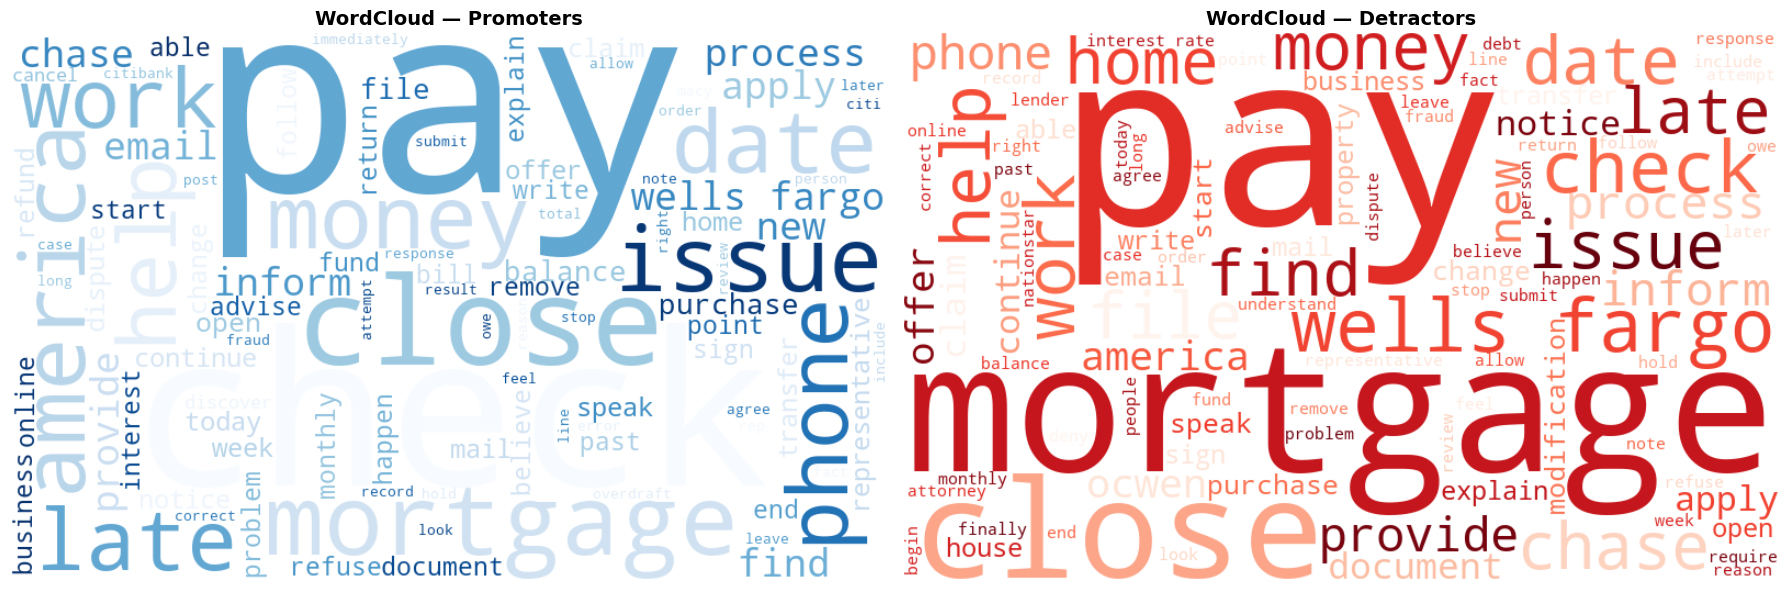

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
segment_pairs = [
    ("Promoter", "Blues", axes[0]),
    ("Detractor", "Reds", axes[1]),
]

for segment, colormap, ax in segment_pairs:
    subset_text = " ".join(df_lda[df_lda["nps_segment"] == segment]["lda_text"].dropna())
    if subset_text.strip():
        wc = WordCloud(
            width=800, height=500,
            background_color="white",
            colormap=colormap,
            max_words=100,
        ).generate(subset_text)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"WordCloud — {segment}s", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## 12. Top 5 Drivers of Dissatisfaction

In [15]:
top5_drivers = nps_by_topic.nsmallest(5, "nps")
print("=== TOP 5 DRIVERS OF DISSATISFACTION ===")
for i, (_, row) in enumerate(top5_drivers.iterrows(), 1):
    print(f"{i}. {row['topic_name']}")
    print(f"   NPS: {row['nps']} | Complaints: {row['n_total']:,} | "
          f"Detractors: {row['pct_detractors']:.1f}%")

=== TOP 5 DRIVERS OF DISSATISFACTION ===
1. Incorrect Charges & Unauthorized Debits
   NPS: -17.87 | Complaints: 6,894 | Detractors: 29.1%
2. Mortgage & Loan Servicing
   NPS: -6.76 | Complaints: 1,774 | Detractors: 25.4%
3. Credit Reporting & Disputes
   NPS: -6.39 | Complaints: 19,493 | Detractors: 25.7%
4. Customer Service & Communication
   NPS: 8.94 | Complaints: 7,059 | Detractors: 20.2%


## 13. Save Updated Features + LDA Model

In [16]:
# Add topic columns back to the main features dataframe
# Re-merge on complaint_id
df_topics = df_lda[["complaint_id", "dominant_topic", "topic_name", "topic_probability", "lda_text"]].copy()

df_full = pd.read_csv(FEATURES_PATH, low_memory=False)
df_full = df_full.merge(df_topics, on="complaint_id", how="left")

df_full.to_csv(FEATURES_PATH, index=False)
print(f"Updated features saved: {len(df_full):,} rows")

# Save LDA model
save_lda_model(lda_model, vectorizer, LDA_MODEL_PATH)
print(f"LDA model + vectorizer saved to {LDA_MODEL_PATH}")

Updated features saved: 35,226 rows
LDA model saved → /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/models/lda_model.pkl
LDA model + vectorizer saved to /Users/nicolaszuleta95/code_nz/cx-intelligence-nps/models/lda_model.pkl


## 14. Conclusions

**Optimal number of topics: k = 4** (best held-out perplexity: −1,130.0)

**Topic summary:**

| Topic | Name | Complaints | % | NPS | % Detractors |
|-------|------|-----------|---|-----|-------------|
| 0 | Incorrect Charges & Unauthorized Debits | 6,894 | 19.5% | **−17.87** | 29.1% |
| 1 | Mortgage & Loan Servicing | 1,774 | 5.0% | −6.76 | 25.4% |
| 2 | Customer Service & Communication | 7,059 | 20.0% | **+8.94** | 20.2% |
| 3 | Credit Reporting & Disputes | 19,493 | 55.3% | −6.39 | 25.7% |

**Top drivers of customer dissatisfaction (ranked by NPS):**
1. **Incorrect Charges & Unauthorized Debits** — NPS −17.87 · 6,894 complaints · 29.1% Detractors  
   Unauthorized debits and incorrect fees generate the most acute customer frustration — customers feel violated, not just inconvenienced.
2. **Credit Reporting & Disputes** — NPS −6.39 · 19,493 complaints · 25.7% Detractors  
   Highest volume topic (55.3% of all complaints). Disputes with credit agencies take months to resolve and directly impact customers' financial lives.
3. **Mortgage & Loan Servicing** — NPS −6.76 · 1,774 complaints · 25.4% Detractors  
   Lowest volume but concentrated dissatisfaction — modification and foreclosure complaints involve high financial stakes.
4. **Customer Service & Communication** — NPS +8.94 · 7,059 complaints · 20.2% Detractors  
   Only positive-NPS topic. Complaints here tend to resolve quickly via explanation; the bank's communication process is functional.

**Key finding:** Volume ≠ urgency. Credit Reporting dominates by volume (55.3%) but ranks only #2 by NPS.
Incorrect Charges is 3.5× smaller but generates 2.7× more NPS damage per complaint.
CX teams should prioritize by NPS impact, not complaint count alone.